# 01 — Khám phá dữ liệu Cora (EDA)

Notebook Tuần 2: thống kê dữ liệu, kiểm tra đồ thị vô hướng, phân bố bậc và nhãn.
Dùng cùng quy ước cho **GCN/GAT** theo Mục 2.4 của kế hoạch.

**Cách chạy:** chọn kernel Python của môi trường đã cài `requirements.txt`, rồi **Run All**.
Jupyter/VS Code cần kernel `ipykernel` trong môi trường đó (`python -m pip install ipykernel` nếu thiếu).
Lần đầu tải Cora cần Internet. Có thể mở notebook từ thư mục gốc hoặc `notebooks/`;
cell đầu tìm thư mục gốc để dữ liệu luôn được lưu tại `data/` của repository.

“Raw edges” bên dưới là số cột `edge_index` **vừa được Planetoid trả về**,
không phải số dòng trích dẫn có hướng trong nguồn dữ liệu ban đầu.


In [1]:
from pathlib import Path
import os

# Keep Planetoid(root='data/') relative to the repository, not notebooks/.
start_dir = Path.cwd().resolve()
project_root = next(
    (p for p in (start_dir, *start_dir.parents)
     if (p / "requirements.txt").is_file() and (p / "README.md").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Mở notebook từ thư mục repository hoặc notebooks/.")
os.chdir(project_root)

import numpy as np
import torch
import torch_geometric
import torch_geometric.transforms as T
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import to_networkx
import networkx as nx
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "figure.dpi": 110,
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("Project root:", project_root)
print("PyTorch:", torch.__version__, "| PyG:", torch_geometric.__version__)


d:\My workspace\Project\AI\gnn-node-link-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: D:\My workspace\Project\AI\gnn-node-link-prediction
PyTorch: 2.7.1+cpu | PyG: 2.7.0


## 1. Tải dữ liệu và thống kê ban đầu

Không truyền transform lúc tải để so sánh trước/sau một cách tường minh.
`Planetoid` mặc định dùng split `public`; không tạo lại train mask.


In [2]:
dataset = Planetoid(root='data/', name='Cora')
raw_data = dataset[0]
raw_edge_count = raw_data.num_edges

print(f"Số nút: {raw_data.num_nodes:,}")
print(f"Raw edges (số cột edge_index): {raw_edge_count:,}")
print(f"Số đặc trưng mỗi nút: {dataset.num_node_features:,}")
print(f"Số lớp: {dataset.num_classes}")
print(f"Đã vô hướng khi tải: {raw_data.is_undirected()}")
print(f"Có self-loop khi tải: {raw_data.has_self_loops()}")
print(
    "Số nút train / val / test:",
    int(raw_data.train_mask.sum()),
    int(raw_data.val_mask.sum()),
    int(raw_data.test_mask.sum()),
)


Số nút: 2,708
Raw edges (số cột edge_index): 10,556
Số đặc trưng mỗi nút: 1,433
Số lớp: 7
Đã vô hướng khi tải: True
Có self-loop khi tải: False
Số nút train / val / test: 140 500 1000


Processing...
Done!


## 2. Chuẩn hóa thành đồ thị vô hướng

Áp dụng `ToUndirected()` lên bản sao; giữ dữ liệu ban đầu để đối chiếu.
Cora qua loader Planetoid thường đã đối xứng, vì vậy số cạnh **có thể giữ nguyên**,
không nhất thiết tăng gấp đôi. Chưa thêm self-loop trong EDA.


In [3]:
data = T.ToUndirected()(raw_data.clone())
assert data.is_undirected(), "Đồ thị sau transform phải vô hướng."
assert data.num_nodes == raw_data.num_nodes
assert torch.equal(data.x, raw_data.x)
assert torch.equal(data.y, raw_data.y)
for mask_name in ("train_mask", "val_mask", "test_mask"):
    assert torch.equal(getattr(data, mask_name), getattr(raw_data, mask_name))

print(f"Edge entries trước / sau: {raw_edge_count:,} / {data.num_edges:,}")
print(f"Thay đổi: {data.num_edges - raw_edge_count:+,}")
print("Vô hướng sau transform:", data.is_undirected())

# An undirected NetworkX graph stores each unordered pair only once.
G = to_networkx(data, to_undirected=True)
assert not G.is_directed()
assert nx.number_of_selfloops(G) == 0, "EDA này giả định Cora chưa thêm self-loop."
assert G.number_of_nodes() == data.num_nodes
assert 2 * G.number_of_edges() == data.num_edges
print(f"Số liên kết vô hướng duy nhất: {G.number_of_edges():,}")


Edge entries trước / sau: 10,556 / 10,556
Thay đổi: +0
Vô hướng sau transform: True
Số liên kết vô hướng duy nhất: 5,278


## 3. Phân bố bậc nút

Tính bậc bằng NetworkX trên đồ thị vô hướng, không cộng gộp cả in-degree và
out-degree từ hai chiều trong `edge_index`. Liệt kê thêm các hub để đối chiếu
với phần đuôi của phân bố.


Bậc min / median / mean / max: 1 / 3.0 / 3.90 / 168
Phân vị 90% / 99%: 7.0 / 19.0
Số nút cô lập (bậc 0): 0
Tỷ lệ nút có bậc <= 5: 84.6%
10 nút bậc cao nhất (node_id, degree):
[(1358, 168), (306, 78), (1701, 74), (1986, 65), (1810, 44), (1623, 42), (2034, 40), (88, 36), (1013, 34), (598, 33)]


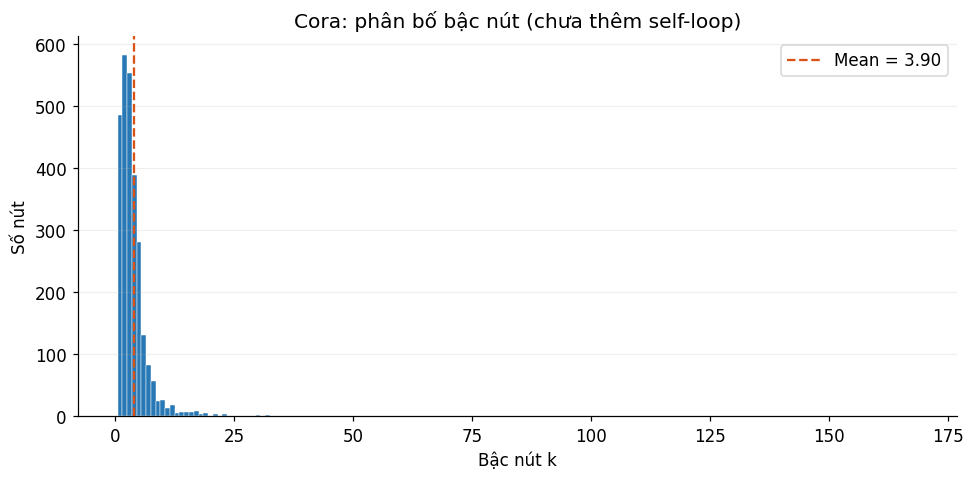

In [4]:
degrees = np.array([G.degree(node) for node in range(data.num_nodes)], dtype=int)
degree_values, degree_counts = np.unique(degrees, return_counts=True)
positive = degree_values > 0  # log(0) is undefined.
isolated_count = int((degrees == 0).sum())
top_nodes = np.argsort(-degrees, kind="stable")[:10]

print(f"Bậc min / median / mean / max: {degrees.min()} / "
      f"{np.median(degrees):.1f} / {degrees.mean():.2f} / {degrees.max()}")
print(f"Phân vị 90% / 99%: {np.percentile(degrees, 90):.1f} / "
      f"{np.percentile(degrees, 99):.1f}")
print(f"Số nút cô lập (bậc 0): {isolated_count}")
print(f"Tỷ lệ nút có bậc <= 5: {(degrees <= 5).mean():.1%}")
print("10 nút bậc cao nhất (node_id, degree):")
print([(int(node), int(degrees[node])) for node in top_nodes])

fig, ax = plt.subplots()
bins = np.arange(degrees.min() - 0.5, degrees.max() + 1.5, 1)
ax.hist(degrees, bins=bins, color="#2878B5", edgecolor="white", linewidth=0.3)
ax.axvline(degrees.mean(), color="#D95319", linestyle="--",
           label=f"Mean = {degrees.mean():.2f}")
ax.set(title="Cora: phân bố bậc nút (chưa thêm self-loop)",
       xlabel="Bậc nút k", ylabel="Số nút")
ax.legend()
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
plt.show()


**Nhận xét — histogram:** Phần lớn nút có ít láng giềng, trong khi một số hub
có bậc cao hơn nhiều; các thống kê phía trên định lượng mức chênh lệch này.
Nếu chỉ cộng thông điệp láng giềng, quy mô tổng hợp dễ phụ thuộc mạnh vào bậc
nút. GCN dùng chuẩn hóa theo bậc để điều tiết đóng góp trên mỗi cạnh, thay vì
để số lượng láng giềng chi phối độ lớn biểu diễn.


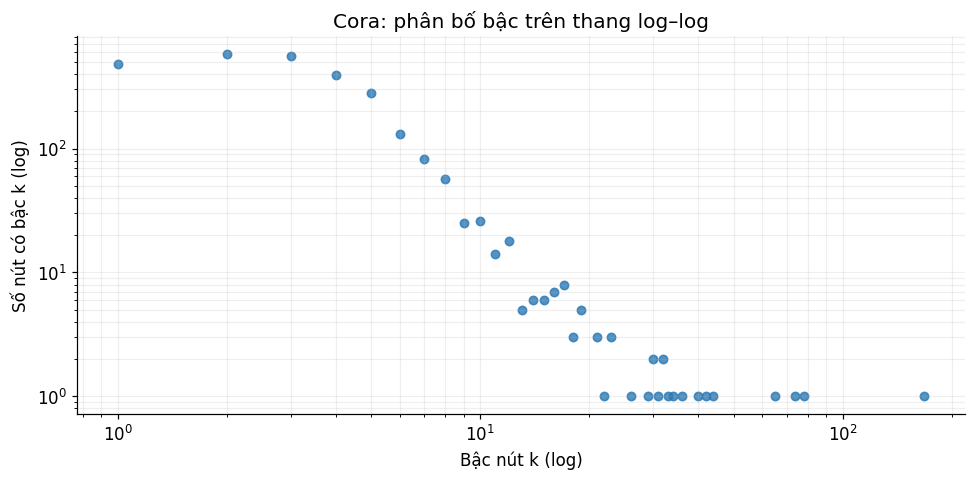

Đã loại 0 nút bậc 0 khỏi biểu đồ log–log.


In [5]:
fig, ax = plt.subplots()
ax.scatter(degree_values[positive], degree_counts[positive],
           color="#2878B5", alpha=0.8, s=30)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set(title="Cora: phân bố bậc trên thang log–log",
       xlabel="Bậc nút k (log)", ylabel="Số nút có bậc k (log)")
ax.grid(which="both", alpha=0.2)
fig.tight_layout()
plt.show()
print(f"Đã loại {isolated_count} nút bậc 0 khỏi biểu đồ log–log.")


**Nhận xét — log–log:** Thang log giúp nhìn rõ những bậc lớn nhưng hiếm gặp,
vốn khó quan sát trên histogram tuyến tính. Phần đuôi thể hiện sự hiện diện
của hub; riêng hình dạng biểu đồ **chưa đủ để kết luận phân bố tuân theo luật lũy thừa**.

Với GCN, thêm self-loop trước rồi tính
$\tilde d_i=d_i+1$ và trọng số cạnh
$1/\sqrt{\tilde d_i\tilde d_j}$ trong
$\hat A=\tilde D^{-1/2}(A+I)\tilde D^{-1/2}$.
Cách này điều tiết thông điệp theo bậc của cả hai đầu cạnh. Bậc dùng trong
hai biểu đồ là bậc **trước self-loop**, không dùng trực tiếp thay cho $\tilde d_i$.


## 4. Phân bố nhãn

Dùng ID lớp do PyG cung cấp, không tự gán tên chủ đề khi chưa xác minh ánh xạ.
Đếm toàn bộ nhãn cho mục đích EDA theo yêu cầu; không dùng nhãn ngoài train
mask để tính loss hoặc chọn siêu tham số.


Class | Toàn graph | Train | Tỷ lệ train trong lớp
    0 |        351 |    20 |  5.70%
    1 |        217 |    20 |  9.22%
    2 |        418 |    20 |  4.78%
    3 |        818 |    20 |  2.44%
    4 |        426 |    20 |  4.69%
    5 |        298 |    20 |  6.71%
    6 |        180 |    20 | 11.11%
Tỷ lệ lớp lớn nhất / nhỏ nhất: 4.54


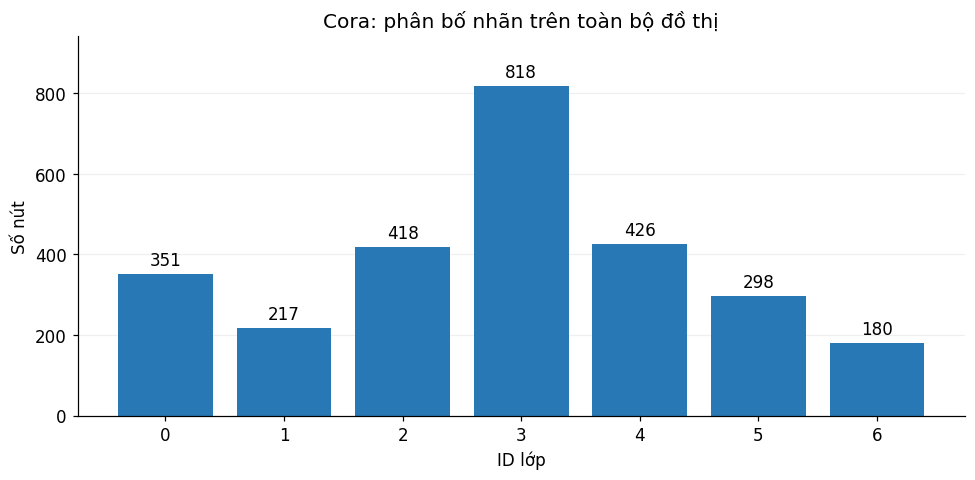

In [6]:
class_ids = np.arange(dataset.num_classes)
all_counts = torch.bincount(data.y, minlength=dataset.num_classes).cpu().numpy()
train_counts = torch.bincount(
    data.y[data.train_mask], minlength=dataset.num_classes
).cpu().numpy()
assert all_counts.sum() == data.num_nodes
assert np.all(train_counts == 20), "Public split Cora phải có 20 nút train/lớp."
assert train_counts.sum() == 140

print("Class | Toàn graph | Train | Tỷ lệ train trong lớp")
for label, total, train in zip(class_ids, all_counts, train_counts):
    print(f"{label:5d} | {total:10d} | {train:5d} | {train / total:6.2%}")
print(f"Tỷ lệ lớp lớn nhất / nhỏ nhất: {all_counts.max() / all_counts.min():.2f}")

fig, ax = plt.subplots()
bars = ax.bar(class_ids, all_counts, color="#2878B5")
ax.bar_label(bars, padding=3)
ax.set(title="Cora: phân bố nhãn trên toàn bộ đồ thị",
       xlabel="ID lớp", ylabel="Số nút", xticks=class_ids,
       ylim=(0, all_counts.max() * 1.15))
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()


**Nhận xét — toàn đồ thị:** Các lớp có số lượng nút khác nhau, nên độ chính
xác tổng thể có thể che khuất chất lượng ở lớp ít mẫu. Vì vậy, kế hoạch báo
cáo cả **Accuracy và Macro-F1**; Macro-F1 cho mỗi lớp trọng số ngang nhau.
Chuẩn hóa bậc của GCN xử lý sự khác biệt cấu trúc láng giềng, **không tự giải
quyết mất cân bằng nhãn**.


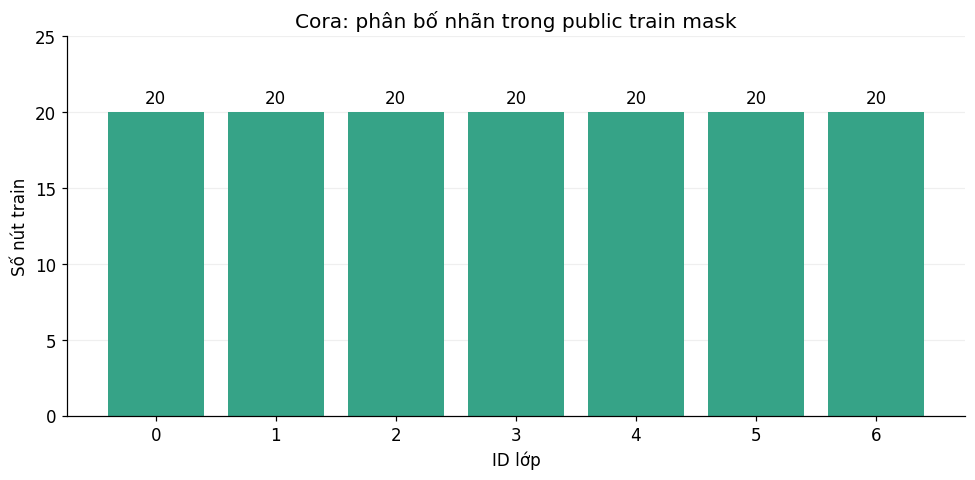

Số nút có nhãn dùng để train: 140 / 2708 (5.17%)


In [7]:
fig, ax = plt.subplots()
bars = ax.bar(class_ids, train_counts, color="#36A387")
ax.bar_label(bars, padding=3)
ax.set(title="Cora: phân bố nhãn trong public train mask",
       xlabel="ID lớp", ylabel="Số nút train", xticks=class_ids, ylim=(0, 25))
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()
print(f"Số nút có nhãn dùng để train: {train_counts.sum()} / {data.num_nodes} "
      f"({train_counts.sum() / data.num_nodes:.2%})")


**Nhận xét — train mask:** Mỗi lớp có đúng **20 nút train**, tổng cộng 140
nút. Tập train cân bằng theo số mẫu mỗi lớp, dù toàn đồ thị không cân bằng;
tỷ lệ nút được chọn trong từng lớp vì thế khác nhau. Với ít nhãn huấn luyện,
GCN/GAT có thể khai thác đặc trưng và cấu trúc láng giềng trong thiết lập
transductive, nhưng loss vẫn chỉ tính trên train mask.

**Kết luận:** Giữ đồ thị vô hướng cho cả GCN và GAT; chú ý các hub khi tổng
hợp thông điệp và tính bậc sau self-loop cho GCN. Giữ public split để so sánh
công bằng, báo cáo Accuracy cùng Macro-F1. Notebook này mô tả toàn bộ graph;
pipeline link prediction phải chia cạnh và loại held-out edges trước khi
message passing theo README.

Tài liệu: [Planetoid](https://pytorch-geometric.readthedocs.io/en/2.7.0/generated/torch_geometric.datasets.Planetoid.html),
[ToUndirected](https://pytorch-geometric.readthedocs.io/en/2.7.0/generated/torch_geometric.transforms.ToUndirected.html).
